# XGBoost

In [11]:
# Install if needed
# !pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBClassifier, XGBRegressor


## Part A: Classification

In [12]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))


Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

[[38  4]
 [ 2 70]]


,Feature,Importance
22,worst perimeter,0.440799
20,worst radius,0.200760
7,mean concave points,0.061267
27,worst concave points,0.057798
25,worst compactness,0.033651
23,worst area,0.025340
11,texture error,0.022951
21,worst texture,0.017368
3,mean area,0.016482
15,compactness error,0.014153


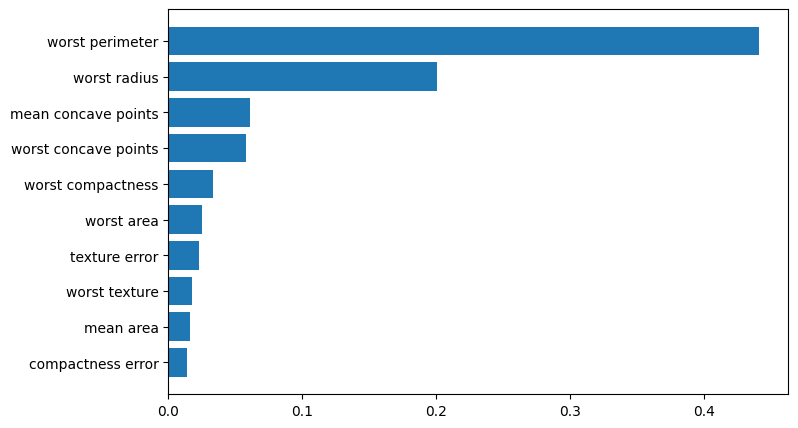

In [13]:
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
}).sort_values("Importance", ascending=False)

display(fi.head(10))
plt.figure(figsize=(8,5))
plt.barh(fi.head(10)["Feature"], fi.head(10)["Importance"])
plt.gca().invert_yaxis()
plt.show()


## Part B: Regression

In [14]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

reg.fit(X_train, y_train)
pred = reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))


MAE: 0.31792398881333284
RMSE: 0.4777813265058776
R2: 0.8257986630523902


,Feature,Importance
0,MedInc,0.541301
5,AveOccup,0.155819
7,Longitude,0.082948
6,Latitude,0.078099
1,HouseAge,0.061669
2,AveRooms,0.041922
3,AveBedrms,0.021217
4,Population,0.017025


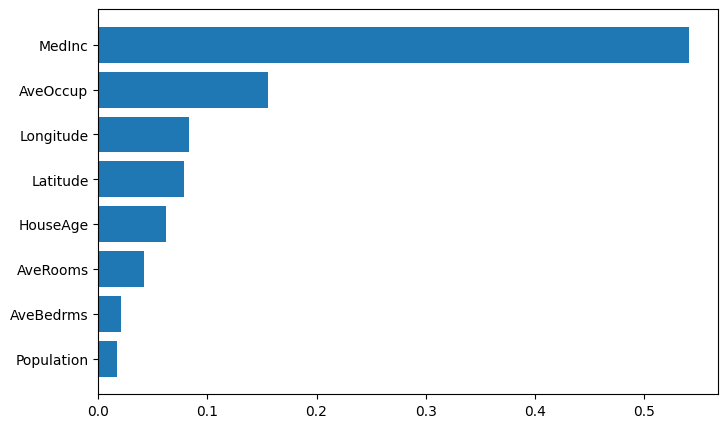

In [15]:
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": reg.feature_importances_
}).sort_values("Importance", ascending=False)

display(fi)
plt.figure(figsize=(8,5))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.show()


## Exercises

- Tune max_depth
- Tune learning_rate
- Tune n_estimators
- Perform cross-validation
- Compare with Random Forest and LightGBM


## For more reference:

1. Unfold Data Science: https://youtu.be/FakVn1RgDms
2. Unfold Data Science: https://youtu.be/pzFr7ske6Tc
3. Unfold Data Science: https://youtu.be/C1ahSmQalZY
4. Thinking Neuron: https://youtu.be/MDsAYsbjXQo
5. Krish Naik: https://youtu.be/gPciUPwWJQQ
6. Krish Naik: https://youtu.be/w-_vmVfpssg
7. CampusX: https://youtu.be/C6aDw4y8qJ0
8. CampusX: https://youtu.be/gmp2tS2joaA
9. CampusX: https://youtu.be/mELtxVUNNrw
10. CampusX: https://youtu.be/0Eo-_5bfers